# 05. Скользящее окно OLS (52 недели)

Оцениваем **М4 (расширенная)** — те же регрессоры, что в `03_regression_analysis.ipynb`: крипто-факторы и расширенный набор внешних (`r_sp500`, `VIX`, `r_dxy`, `r_gold`, `d_yield_10y`, `epu`).

На каждом конце окна из **52 недель** обучается OLS; стандартные ошибки — **Newey–West (HAC)** с лагом по формуле из ноутбука 03. На графиках: точечная оценка $\beta(t)$ и лента $\pm 1.96\,\widehat{SE}(t)$.

Исследовательский фокус: динамика связи BTC с **S&P 500**, **VIX** и **золотом**.


Точек на графиках: 371 (окно 52 нед.)


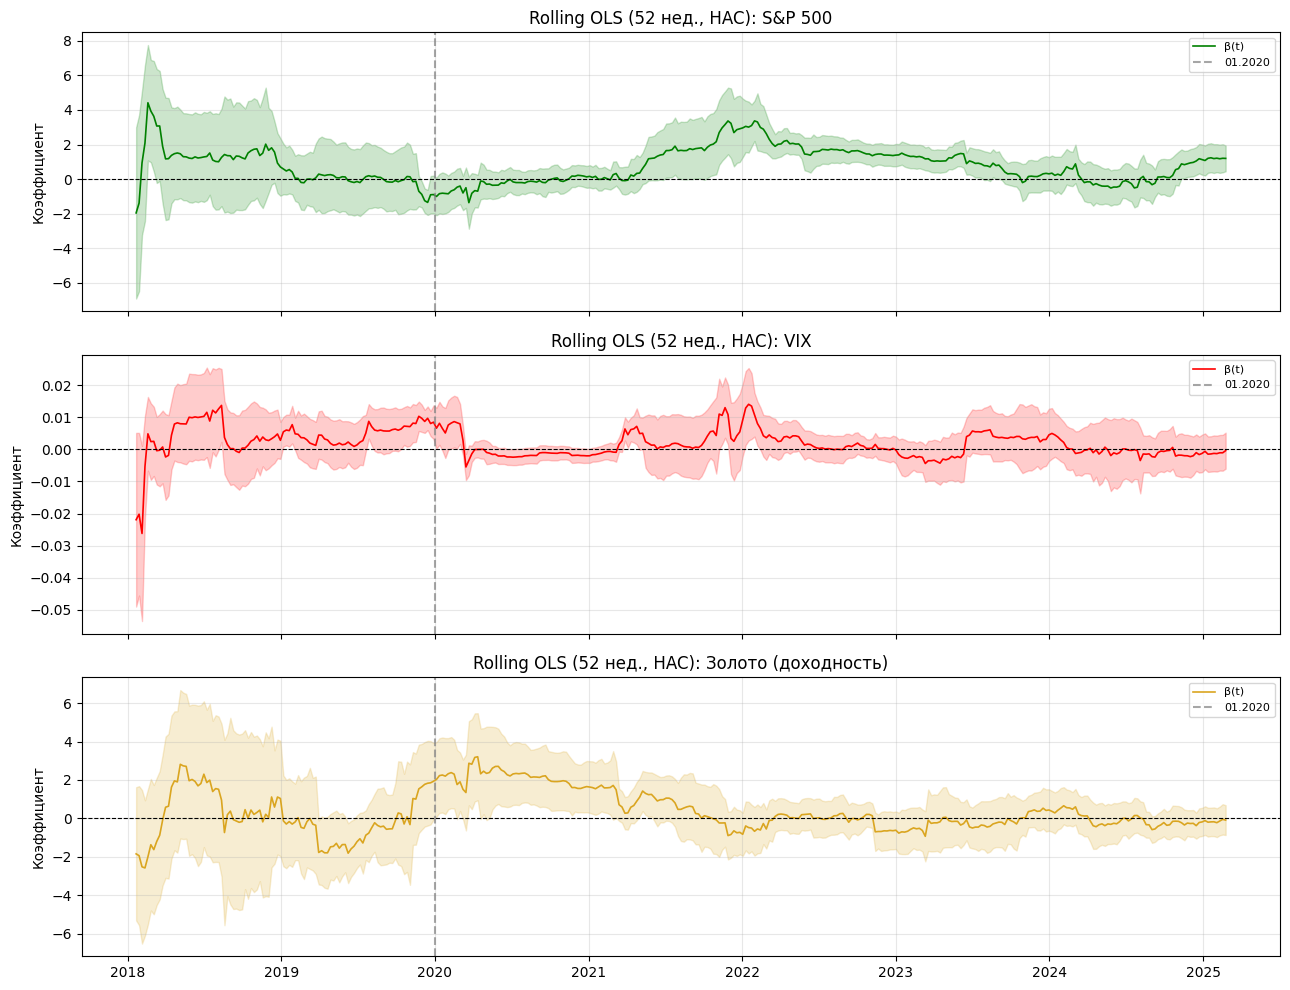

Сохранено: data/processed/rolling_ols_beta.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/merged_weekly.csv', index_col='date', parse_dates=True)
Y_VAR = 'r_btc'
CRYPTO_VARS = ['r_btc_lag', 'log_volume_btc', 'google_trends']
EXTERNAL_VARS_EXT = ['r_sp500', 'vix', 'r_dxy', 'r_gold', 'd_yield_10y', 'epu']
ALL_VARS_EXT = CRYPTO_VARS + EXTERNAL_VARS_EXT

window = 52
track = ['r_sp500', 'vix', 'r_gold']

coef_hist = {v: [] for v in track}
se_hist = {v: [] for v in track}
end_dates = []

for end in range(window - 1, len(df)):
    sub = df.iloc[end - window + 1 : end + 1]
    sample = sub[[Y_VAR] + ALL_VARS_EXT].dropna()
    if len(sample) != window:
        continue
    y = sample[Y_VAR]
    X = sm.add_constant(sample[ALL_VARS_EXT])
    fit = sm.OLS(y, X).fit()
    nw_lags = max(1, int(np.floor(4 * (len(sample) / 100) ** (2 / 9))))
    r = fit.get_robustcov_results(cov_type='HAC', maxlags=nw_lags)
    names = list(r.model.exog_names)
    end_dates.append(sample.index[-1])
    for v in track:
        j = names.index(v)
        coef_hist[v].append(float(np.asarray(r.params)[j]))
        se_hist[v].append(float(np.asarray(r.bse)[j]))

end_dates = pd.DatetimeIndex(end_dates)
print(f'Точек на графиках: {len(end_dates)} (окно {window} нед.)')

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
colors = {'r_sp500': 'green', 'vix': 'red', 'r_gold': 'goldenrod'}
titles = {'r_sp500': 'S&P 500', 'vix': 'VIX', 'r_gold': 'Золото (доходность)'}
for ax, v in zip(axes, track):
    beta = np.array(coef_hist[v])
    se = np.array(se_hist[v])
    ci = 1.96 * se
    ax.plot(end_dates, beta, color=colors[v], lw=1.2, label='β(t)')
    ax.fill_between(end_dates, beta - ci, beta + ci, alpha=0.2, color=colors[v])
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axvline(pd.Timestamp('2020-01-01'), color='gray', ls='--', alpha=0.7, label='01.2020')
    ax.set_ylabel('Коэффициент')
    ax.set_title(f'Rolling OLS ({window} нед., HAC): {titles[v]}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../data/processed/rolling_ols_beta.png', dpi=100, bbox_inches='tight')
plt.show()
print('Сохранено: data/processed/rolling_ols_beta.png')
